# Análisis Exploratorio y Modelo RNA para Predicción de Rating de Vinos

In [15]:
import pandas as pd

df = pd.read_csv('../NOTEBOOKS DEL AULA/datasets/wines_SPA.csv')
df.head()

,winery,wine,year,rating,num_reviews,country,region,price,type,body,acidity
0,Teso La Monja,Tinto,2013,4.9,58,Espana,Toro,995.00,Toro Red,5.0,3.0
1,Artadi,Vina El Pison,2018,4.9,31,Espana,Vino de Espana,313.50,Tempranillo,4.0,2.0
2,Vega Sicilia,Unico,2009,4.8,1793,Espana,Ribera del Duero,324.95,Ribera Del Duero Red,5.0,3.0
3,Vega Sicilia,Unico,1999,4.8,1705,Espana,Ribera del Duero,692.96,Ribera Del Duero Red,5.0,3.0
4,Vega Sicilia,Unico,1996,4.8,1309,Espana,Ribera del Duero,778.06,Ribera Del Duero Red,5.0,3.0


## Información general del dataset

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   winery       7500 non-null   object 
 1   wine         7500 non-null   object 
 2   year         7498 non-null   object 
 3   rating       7500 non-null   float64
 4   num_reviews  7500 non-null   int64  
 5   country      7500 non-null   object 
 6   region       7500 non-null   object 
 7   price        7500 non-null   float64
 8   type         6955 non-null   object 
 9   body         6331 non-null   float64
 10  acidity      6331 non-null   float64
dtypes: float64(4), int64(1), object(6)
memory usage: 644.7+ KB


## Estadísticos descriptivos

In [17]:
df.describe(include='all')

,winery,wine,year,rating,num_reviews,country,region,price,type,body,acidity
count,7500,7500,7498,7500.000000,7500.000000,7500,7500,7500.000000,6955,6331.000000,6331.000000
unique,480,847,71,NaN,NaN,1,76,NaN,21,NaN,NaN
top,Contino,Reserva,2011,NaN,NaN,Espana,Rioja,NaN,Rioja Red,NaN,NaN
freq,457,467,1190,NaN,NaN,7500,2440,NaN,2357,NaN,NaN
mean,NaN,NaN,NaN,4.254933,451.109067,NaN,NaN,60.095822,NaN,4.158427,2.946612
std,NaN,NaN,NaN,0.118029,723.001856,NaN,NaN,150.356676,NaN,0.583352,0.248202
min,NaN,NaN,NaN,4.200000,25.000000,NaN,NaN,4.990000,NaN,2.000000,1.000000
25%,NaN,NaN,NaN,4.200000,389.000000,NaN,NaN,18.900000,NaN,4.000000,3.000000
50%,NaN,NaN,NaN,4.200000,404.000000,NaN,NaN,28.530000,NaN,4.000000,3.000000
75%,NaN,NaN,NaN,4.200000,415.000000,NaN,NaN,51.350000,NaN,5.000000,3.000000


## Valores nulos

In [18]:
df.isna().sum()

winery            0
wine              0
year              2
rating            0
num_reviews       0
country           0
region            0
price             0
type            545
body           1169
acidity        1169
dtype: int64

## Matriz de correlación numérica

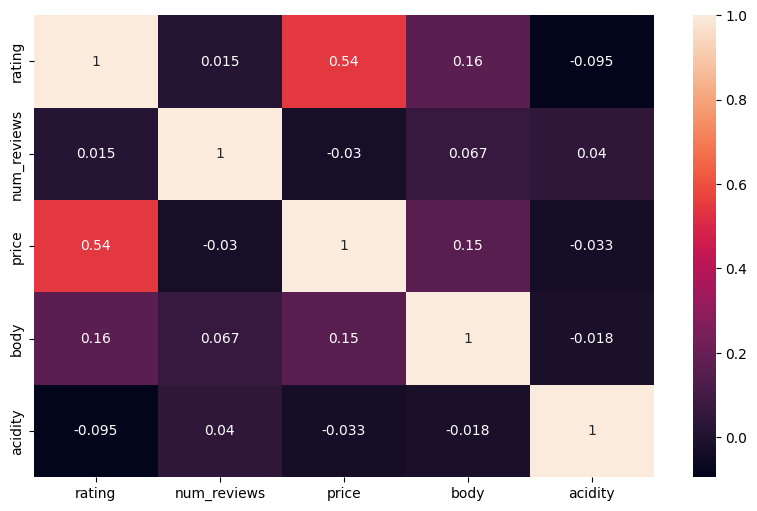

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)
plt.show()

## Preprocesamiento de datos

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import tensorflow as tf

X = df.drop('rating', axis=1)
X = X.fillna({
    col: "Desconocido" for col in X.select_dtypes(include='object')
})
X = X.fillna({
    col: X[col].median() for col in X.select_dtypes(include=['int64','float64'])
})

y = df['rating']

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()

# Create OneHotEncoder in a way compatible with different scikit-learn versions
try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)
except TypeError:
    # Newer scikit-learn renamed 'sparse' to 'sparse_output'
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

preprocess = ColumnTransformer([
    ('cat', ohe, cat_cols),
    ('num', StandardScaler(), num_cols)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [22]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6000 entries, 4664 to 7270
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   winery       6000 non-null   object 
 1   wine         6000 non-null   object 
 2   year         6000 non-null   object 
 3   num_reviews  6000 non-null   int64  
 4   country      6000 non-null   object 
 5   region       6000 non-null   object 
 6   price        6000 non-null   float64
 7   type         6000 non-null   object 
 8   body         6000 non-null   float64
 9   acidity      6000 non-null   float64
dtypes: float64(3), int64(1), object(6)
memory usage: 515.6+ KB


## Modelo RNA

In [23]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Fit and transform the data with the preprocessor
X_train_p = preprocess.fit_transform(X_train)
X_test_p = preprocess.transform(X_test)

# Ensure dense numpy arrays (ColumnTransformer + OneHotEncoder with sparse=False should already return dense)
import numpy as np
if hasattr(X_train_p, "toarray") or hasattr(X_train_p, "A") :
    X_train_p = X_train_p.toarray() if hasattr(X_train_p, "toarray") else X_train_p.A
    X_test_p = X_test_p.toarray() if hasattr(X_test_p, "toarray") else X_test_p.A

input_dim = X_train_p.shape[1]

model = Sequential([
    Dense(64, activation='relu', input_shape=(input_dim,)),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# Callbacks: early stopping and save best model
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
mc = ModelCheckpoint('best_rna_wine_model.keras', monitor='val_loss', save_best_only=True)

# Train (increase epochs and rely on EarlyStopping)
history = model.fit(X_train_p, y_train, epochs=100, batch_size=32, validation_split=0.2, callbacks=[es, mc])

c:\Users\grach\Documents\proyectos\IABD\CEIABD_25_26\.venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 4.0991 - val_loss: 0.0734
Epoch 2/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 4.0991 - val_loss: 0.0734
Epoch 2/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0350 - val_loss: 0.0281
Epoch 3/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0350 - val_loss: 0.0281
Epoch 3/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0102 - val_loss: 0.0203
Epoch 4/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0102 - val_loss: 0.0203
Epoch 4/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 0.0050 - val_loss: 0.0182
Epoch 5/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 0.0050 - val_loss: 0.0182
Epoch 5/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0027 - val_loss: 0.0177
Epoch 6/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0027 - val_loss: 0.0177
Epoch 6/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0022 - val_loss: 0.0177
Epoch 7/100
150/150 ━━━━━━━━━━━━━━

## Guardar el modelo y el preprocesado

In [24]:
import pickle

# Guardar el preprocesador
with open("preprocess.pkl", "wb") as f:
    pickle.dump(preprocess, f)

# El callback ModelCheckpoint guarda el mejor modelo en 'best_rna_wine_model.keras'
# Guardar también el modelo final (opcional)
model.save("rna_wine_model_v3.keras", save_format="keras")

print("Preprocessor y modelos guardados correctamente. Best model: 'best_rna_wine_model.keras'")

Preprocessor y modelos guardados correctamente. Best model: 'best_rna_wine_model.keras'


## Evaluación del modelo

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
MSE: 0.0194
RMSE: 0.1394
R2: -0.2801
MSE: 0.0194
RMSE: 0.1394
R2: -0.2801


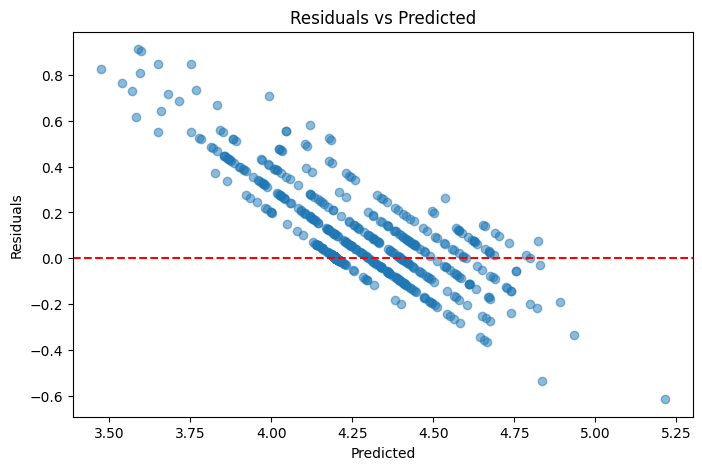

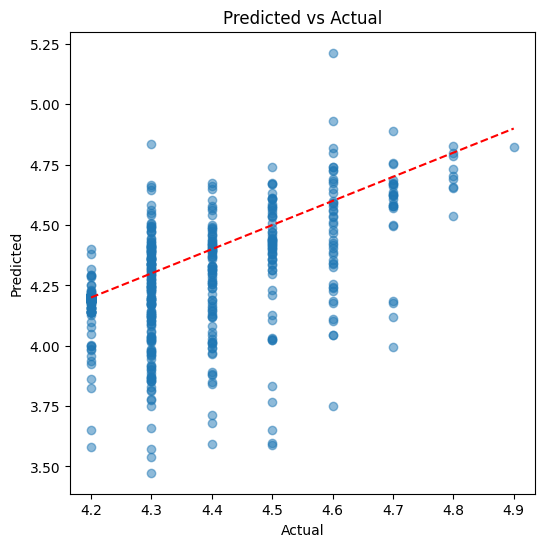

In [25]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# Load the best saved model
best_model = load_model('best_rna_wine_model.keras')

# Ensure X_test_p is dense (if needed)
if hasattr(X_test_p, "toarray") or hasattr(X_test_p, "A") :
    X_test_p = X_test_p.toarray() if hasattr(X_test_p, "toarray") else X_test_p.A

preds = best_model.predict(X_test_p)
mse = mean_squared_error(y_test, preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, preds)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")

# Residuals plot
residuals = y_test - preds.flatten()
plt.figure(figsize=(8,5))
plt.scatter(preds, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')
plt.show()

# Predicted vs Actual
plt.figure(figsize=(6,6))
plt.scatter(y_test, preds, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Predicted vs Actual')
plt.show()

## Resumen de cambios y recomendaciones


He actualizado el notebook para mejorar la compatibilidad con Keras, añadir control de entrenamiento y ampliar la evaluación. A continuación se resumen los cambios y recomendaciones concretas:


- OneHotEncoder ahora usa `sparse=False` para producir matrices densas compatibles con Keras.
- El preprocesado se aplica con `preprocess.fit_transform` y se asegura que el resultado sea un `ndarray` denso.
- El modelo se construye después de conocer `input_dim` (número de features tras el preprocess).
- Se añadieron callbacks: `EarlyStopping` (patience=5, restaura mejores pesos) y `ModelCheckpoint` (guarda el mejor modelo en `best_rna_wine_model.keras`).
- Se aumentaron las épocas a 100 y se confía en `EarlyStopping` para detener cuando sea apropiado.
- El pipeline de guardado ahora serializa `preprocess` en `preprocess.pkl` y guarda el modelo final en `rna_wine_model_v3.keras`. El mejor modelo queda en `best_rna_wine_model.keras`.
- Evaluación ampliada: se calcula MSE, RMSE y R2. Se generan plots de residuos y Predicted vs Actual para diagnóstico visual.

Recomendaciones adicionales:

1. Si alguna columna categórica tiene alta cardinalidad, considerar embeddings o encoding con regularización (target encoding).
2. Añadir `random`/`np.random`/`tf` seeds para reproducibilidad completa.
3. Versionar artefactos (anotar versiones de `scikit-learn` y `tensorflow` en un archivo `metadata.json` o en los nombres de los archivos guardados).
4. Considerar validación cruzada para evaluar robustez del modelo.

Si quieres, puedo:
- Insertar esta celda al inicio del notebook en lugar del final.
- Añadir `seed` fijo y un bloque que imprime versiones de librerías.
- Reemplazar OneHotEncoder por `sparse_output=False` si usas scikit-learn 1.5+ (si procede).